<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-5---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Entregable_Tarea_5_1_Alfaro_Cruz_Perez_Rupit_Medea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contaminación Atmosférica y Calidad del Aire (PM2.5)

## Exploración y Preprocesamiento
Rúbrica: 15% Manejo adecuado de valores nulos, codificación de categóricas y escalamiento de variables (crítico para GLM, $L_1$ / $L_2$ y Redes Neuronales).

## Resumen de la programación realizada en este código

1) Se revisa la información para poder determinar el tipo de datos, sus estadísticos y sus representaciones mediante gráficas para poder decir el tratamiento de los datos.
2) Se transforma la única variable categórica (cbwd) y se separó por columnas para poderla utilizar en el modelado.

3) Se crean tres ejercicios de df imputados, el primero con medianas, el segundo con medias y el tercero con mice.
4) Se decide para lo que sigue en el código, trabajar con el df al cuál se le eliminaron los nulos  y con mice para hacer un comparativo entre los modelos.

Observaciones:  

5) La información cuenta con registros por hora durante todos los días a lo largo de los 5 años.  
6) Se encuentra que: La información solo tenía datos con NA en la columna por modelar (pm2.5) y representan menos del 4.72% del total de datos.
7) Hay dos columns (ls y lr) que más del 75% de sus datos son cero por lo que al analizarlos se categorizan varios de sus valores como outliers.

In [1]:
# Incluir librerías necesarias para procesamiento y graficación
import pandas as pd # Manejo de datos en tablas
import numpy as np # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas
import seaborn as sns  # Gráficas más avanzadas
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.compose import ColumnTransformer

In [2]:
# Importar la información
df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")

In [3]:
# Se revisa el número de registros
print("Numero de filas del dataset: ", len(df))

Numero de filas del dataset:  43824


In [8]:
# Mostrar las primeras 5 filas
df.sample(10)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
22584,22585,2012,7,30,0,NaN,22,25.0,1001.0,NW,1.79,0,0
10596,10597,2011,3,18,12,NaN,-10,13.0,1013.0,NW,13.86,0,0
35035,35036,2013,12,30,19,36.0,-22,6.0,1015.0,NW,132.30,0,0
24815,24816,2012,10,30,23,8.0,-12,10.0,1022.0,NW,27.71,0,0
31635,31636,2013,8,11,3,106.0,24,27.0,1007.0,SE,6.71,0,0
5272,5273,2010,8,8,16,119.0,21,32.0,1002.0,SE,10.29,0,0
31840,31841,2013,8,19,16,12.0,7,34.0,1008.0,cv,0.89,0,0
8753,8754,2010,12,31,17,20.0,-20,-4.0,1029.0,NW,518.55,0,0
1081,1082,2010,2,15,1,27.0,-22,-7.0,1037.0,NE,8.04,0,0
29443,29444,2013,5,11,19,26.0,-8,26.0,994.0,NW,54.09,0,0


# Glosario de Columnas Relevantes

Se estandarizaron todos los nombres de las columnas a mayúsculas y sin símbolos

pm2.5 --> PM25: Concentración de partículas PM2.5 (material particulado fino)

DEWP: Punto de rocío (Dew Point)

TEMP: Temperatura ambiente

PRES: Presión atmosférica

cbwd --> WIND_DIRECTION : Dirección combinada del viento
  - NW: Viento del noroeste

  - NE: Viento del noreste

  - SE: Viento del sureste

  - cv: Calm Variable (viento muy debil o dirección variable). *Combinación de las tres anteriores, sin rumbo fijo.

lws --> WIND_SPEED: velocidad acumulada del viento

ls--> SNOW: Horas acumuladas de nieve

lr --> RAIN: Horas acumuladas de lluvia





In [9]:
# Revisar el tipos de datos y columnas presentes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [11]:
#Renombrar encabezados para sevitar problemas en la programación
df = df.rename(columns={"No": "NO",
                        "year": "YEAR",
                        "month": "MONTH",
                        "day": "DAY",
                        "hour": "HOUR",
                        "pm2.5": "PM25",
                        "DEWP": "DEWPOINT",
                        "TEMP": "TEMP",
                        "PRES": "PRESION",
                        "cbwd": "WIND_DIRECTION",
                        "Iws": "WIND_SPEED",
                        "Is": "SNOW",
                        "Ir": "RAIN"})
df.info()  # Revisar el tipos de datos y columnas presentes

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NO              43824 non-null  int64  
 1   YEAR            43824 non-null  int64  
 2   MONTH           43824 non-null  int64  
 3   DAY             43824 non-null  int64  
 4   HOUR            43824 non-null  int64  
 5   PM25            41757 non-null  float64
 6   DEWPOINT        43824 non-null  int64  
 7   TEMP            43824 non-null  float64
 8   PRESION         43824 non-null  float64
 9   WIND_DIRECTION  43824 non-null  str    
 10  WIND_SPEED      43824 non-null  float64
 11  SNOW            43824 non-null  int64  
 12  RAIN            43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [13]:
# Se quería entender la cantidad y granularidad de la informacion por FECHA.
# Creación de una columna con la fecha a partir de year, month, day y hour.
# Mostrar resultados
df['FECHA'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY', 'HOUR']]) # Crea una columna con la fecha con hora
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA'].min()} hasta {df['FECHA'].max()}")

# Observamos que las mediciones son cada hora
display(df["HOUR"].value_counts())

# Creación de otra SIN columna HOUR
df['FECHA_SIN_H'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']]) # Crea una columna con la fecha
print("Rango de fechas del dataset:")
print(f"Desde: {df['FECHA_SIN_H'].min()} hasta {df['FECHA_SIN_H'].max()}")

# Frecuencia de observaciones por día
display(df["FECHA"].value_counts())
display(df["FECHA_SIN_H"].value_counts())


Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 23:00:00


HOUR
0     1826
1     1826
2     1826
3     1826
4     1826
5     1826
6     1826
7     1826
8     1826
9     1826
10    1826
11    1826
12    1826
13    1826
14    1826
15    1826
16    1826
17    1826
18    1826
19    1826
20    1826
21    1826
22    1826
23    1826
Name: count, dtype: int64

Rango de fechas del dataset:
Desde: 2010-01-01 00:00:00 hasta 2014-12-31 00:00:00


FECHA
2010-01-01 00:00:00    1
2010-01-01 01:00:00    1
2010-01-01 02:00:00    1
2010-01-01 03:00:00    1
2010-01-01 04:00:00    1
                      ..
2014-12-31 19:00:00    1
2014-12-31 20:00:00    1
2014-12-31 21:00:00    1
2014-12-31 22:00:00    1
2014-12-31 23:00:00    1
Name: count, Length: 43824, dtype: int64

FECHA_SIN_H
2010-01-01    24
2010-01-02    24
2010-01-03    24
2010-01-04    24
2010-01-05    24
              ..
2014-12-27    24
2014-12-28    24
2014-12-29    24
2014-12-30    24
2014-12-31    24
Name: count, Length: 1826, dtype: int64

In [15]:
# Se revisa la configuración del df y las nuevas columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   NO              43824 non-null  int64         
 1   YEAR            43824 non-null  int64         
 2   MONTH           43824 non-null  int64         
 3   DAY             43824 non-null  int64         
 4   HOUR            43824 non-null  int64         
 5   PM25            41757 non-null  float64       
 6   DEWPOINT        43824 non-null  int64         
 7   TEMP            43824 non-null  float64       
 8   PRESION         43824 non-null  float64       
 9   WIND_DIRECTION  43824 non-null  str           
 10  WIND_SPEED      43824 non-null  float64       
 11  SNOW            43824 non-null  int64         
 12  RAIN            43824 non-null  int64         
 13  FECHA           43824 non-null  datetime64[us]
 14  FECHA_SIN_H     43824 non-null  datetime64[us]
dtypes: datetime64

In [14]:
# Se revisa un ejemplo de 10 registros del df
df.sample(10)

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H
20846,20847,2012,5,18,14,134.0,13,29.0,1005.0,SE,3.13,0,0,2012-05-18 14:00:00,2012-05-18
39633,39634,2014,7,10,9,28.0,14,31.0,1001.0,NW,12.52,0,0,2014-07-10 09:00:00,2014-07-10
7802,7803,2010,11,22,2,23.0,-10,-1.0,1021.0,cv,1.34,0,0,2010-11-22 02:00:00,2010-11-22
14171,14172,2011,8,14,11,110.0,26,28.0,1002.0,SE,3.58,0,0,2011-08-14 11:00:00,2011-08-14
32508,32509,2013,9,16,12,54.0,12,25.0,1011.0,cv,2.68,0,0,2013-09-16 12:00:00,2013-09-16
14148,14149,2011,8,13,12,135.0,25,29.0,1000.0,SE,29.97,0,0,2011-08-13 12:00:00,2011-08-13
43076,43077,2014,11,30,20,31.0,-31,0.0,1028.0,NW,142.17,0,0,2014-11-30 20:00:00,2014-11-30
13938,13939,2011,8,4,18,117.0,21,29.0,1004.0,SE,20.56,0,0,2011-08-04 18:00:00,2011-08-04
2772,2773,2010,4,26,12,18.0,-7,12.0,1011.0,SE,3.13,0,0,2010-04-26 12:00:00,2010-04-26
37425,37426,2014,4,9,9,162.0,8,19.0,1010.0,NE,1.79,0,0,2014-04-09 09:00:00,2014-04-09


In [16]:
# Análisis de métricas principales de la información
# Estadísticas básicas sin considerar las fechas ni variables categóricas
df.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN
count,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


Notas:
- El rango de las variables (diferente entre ellas) puede afectar el modelo por lo que es posible que se deba normalizar
- SNOW y RAIN tienen más del 75% de los datos en ceros.

En este bloque revisamos los OUTLIERS de diferentes columnas,variando el percentil y haciendo zoom o haciendo conteos

No eliminamos datos.

In [17]:
# Revisamos las cifras mayores a cierto porcentil de manera manual ya que el crecimiento de la variable pm2.5 en el Q_4 es de 137 y su máximo es 994.
# Utilizamos el P_75=137 , P_90=221  y P_99=420
# En este bloque revisamos los outliers variando el percentil, no eliminamos dato.
threshold = df['PM25'].quantile(0.75)
filtered_df = df[df['PM25'] >= threshold]
filtered_df['PM25'].describe()

count    10506.000000
mean       226.650010
std         87.597093
min        137.000000
25%        162.000000
50%        200.000000
75%        265.000000
max        994.000000
Name: PM25, dtype: float64

In [19]:
# Se revisa con un conteo los valores de SNOW y RAIN por la cantidad de ceros que presentan
print(df[["SNOW", "RAIN"]].value_counts())

SNOW  RAIN
0     0       41648
      1         529
      2         316
      3         214
      4         136
              ...  
27    0           1
0     33          1
      34          1
      35          1
      36          1
Name: count, Length: 64, dtype: int64


Revisión de vaciós y el resultado es que sólo hay en la columna pm2.5 y son menos del 4.72%

In [20]:
# Revisión de datos nulos de la información
df.isnull().sum()

NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
FECHA_SIN_H          0
dtype: int64

In [22]:
# Porcentaje de vacíos en la información por modelar
x = 2067/43824*100
print(round(x, 3), '%')

4.717 %


# **En esta sección se grafican las 8 variables del df.**
No consideramos para graficar las relacionadas a las fechas.

Se utilizan:
- Histograma para la variable pm2.5
- Series de tiempo para todas las variables continuas
- Grafica de barras para las variables categóricas

<function matplotlib.pyplot.show(close=None, block=None)>

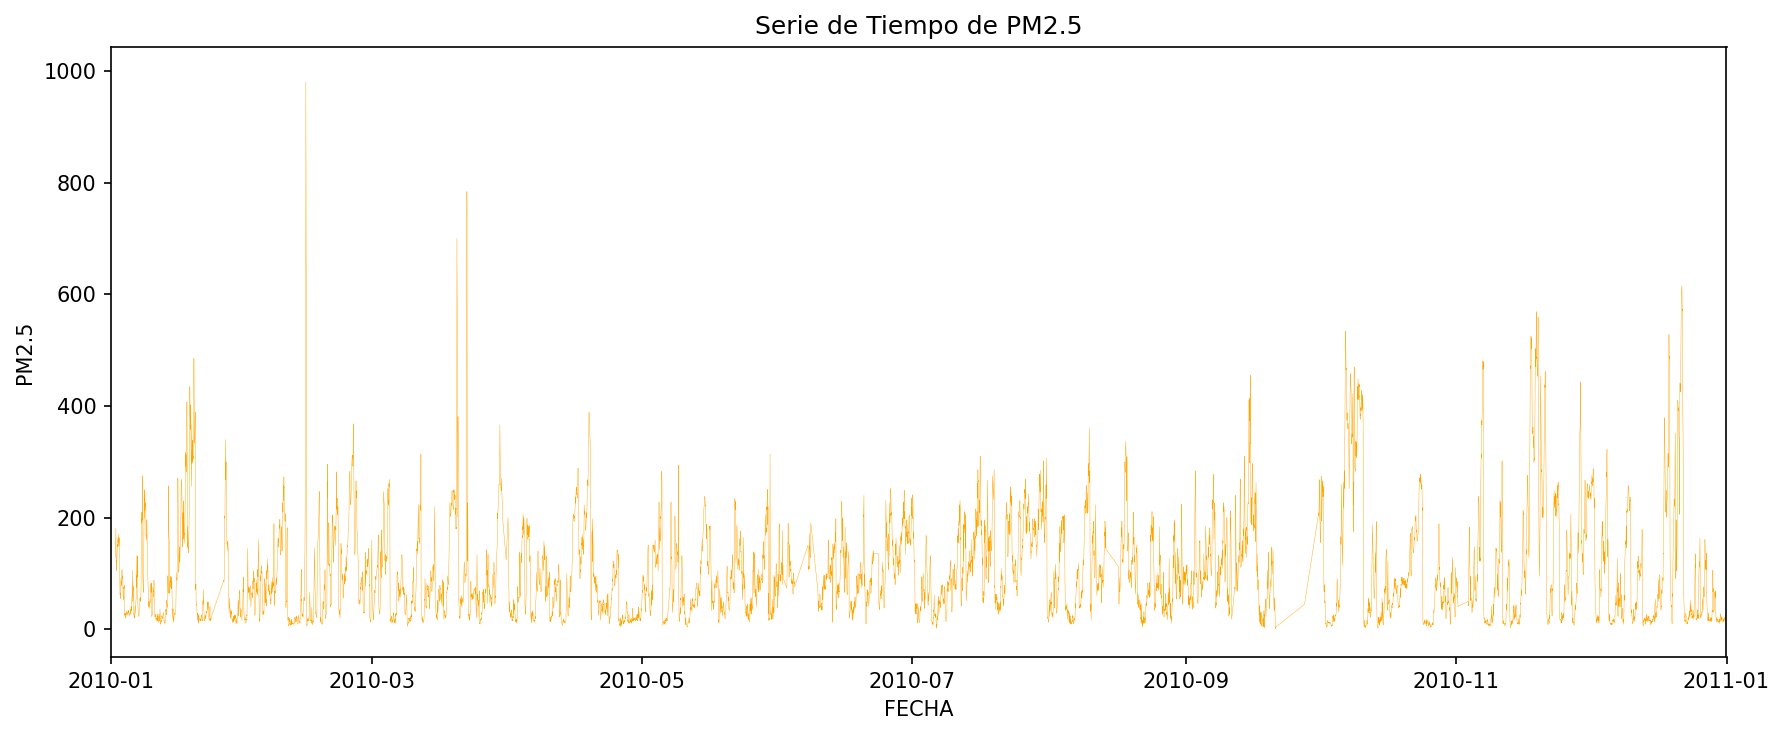

In [23]:
# # SERIE DE TIEMPO
# Serie de PM2.5,
plt.rcParams["figure.dpi"] = 150
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="FECHA", y="PM25",
             data=df,
             linewidth=0.2,
             color='orange'
            )
ax.set(
    ylabel="PM2.5",
    title="Serie de Tiempo de PM2.5",
)
ax.tick_params(axis="both", labelsize=10)

plt.xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2011-01-01"))
plt.tight_layout()
plt.show

# Time Series por año
# Pendiente ver si sale...

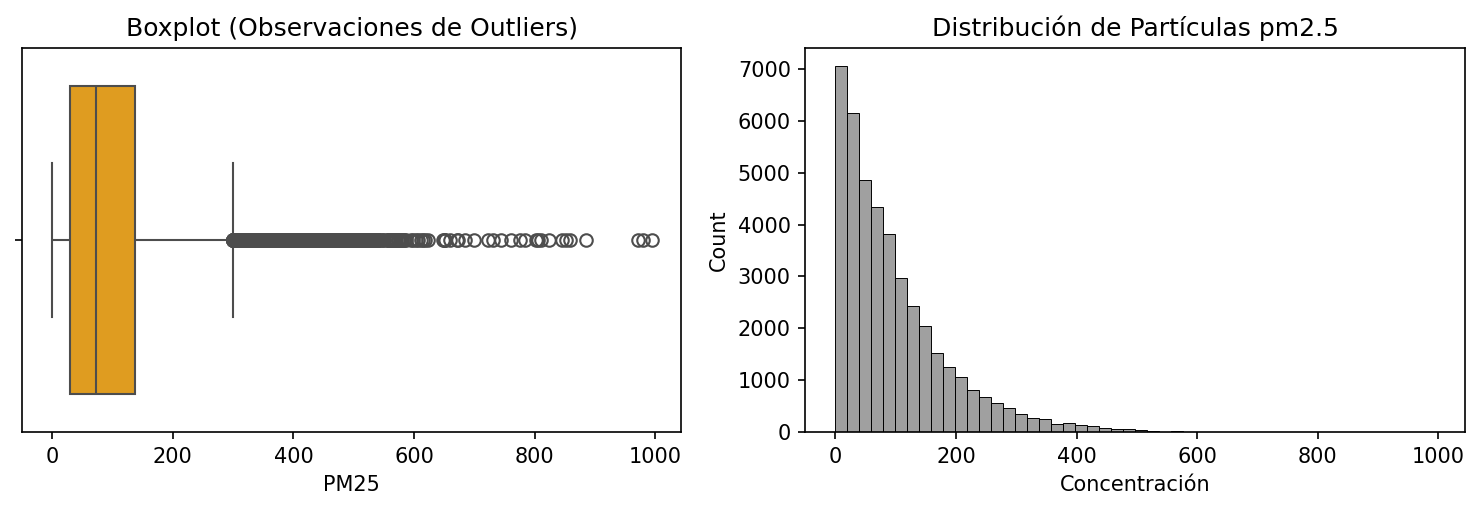

In [24]:
# HISTOGRAMA Y GRAFICO  DE CAJA Y BIGOTES
# Para elegir el metodo de imputación, observamos los outliers del dataset
plt.figure(figsize=(10, 3.5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["PM25"], color='orange')
plt.title("Boxplot (Observaciones de Outliers)")

# Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 2)
sns.histplot(df['PM25'], bins=50, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración')

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

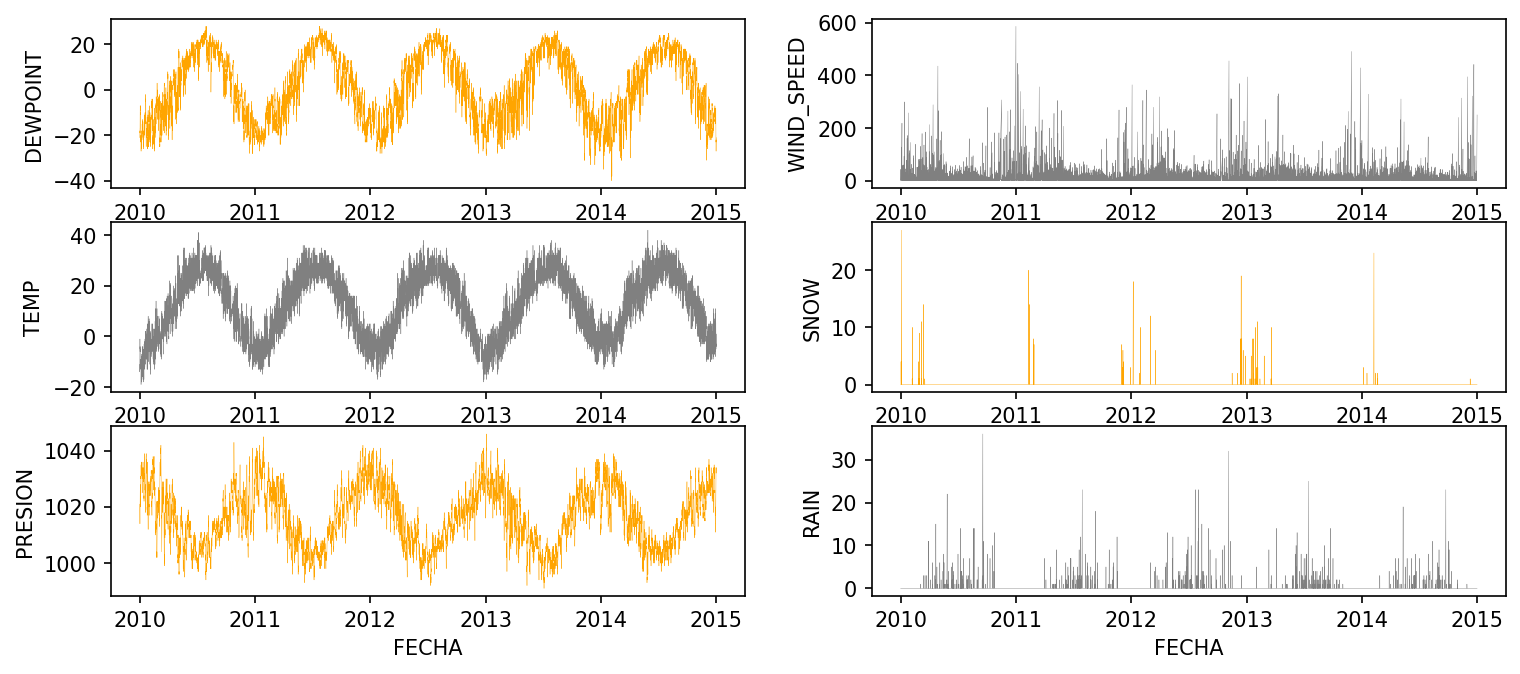

In [25]:
# SERIES DE TIEMPO
# La recomendación de las series de tiempo (en un mismo figure) para todas las variables
plt.rcParams["figure.dpi"] = 150

fig, axs = plt.subplots(3,2, figsize=(12,5))
sns.lineplot(x="FECHA", y="DEWPOINT", data=df, color='orange', linewidth=0.2, ax=axs[0,0])
sns.lineplot(x="FECHA", y="TEMP", data=df, color='grey',linewidth=0.2, ax=axs[1,0])
sns.lineplot(x="FECHA", y="PRESION", data=df,color='orange', linewidth=0.2, ax=axs[2,0])
sns.lineplot(x="FECHA", y="WIND_SPEED", data=df, color='grey', linewidth=0.2, ax=axs[0,1])
sns.lineplot(x="FECHA", y="SNOW", data=df, color='orange', linewidth=0.2, ax=axs[1,1])
sns.lineplot(x="FECHA", y="RAIN", data=df,color='grey', linewidth=0.2, ax=axs[2,1])

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

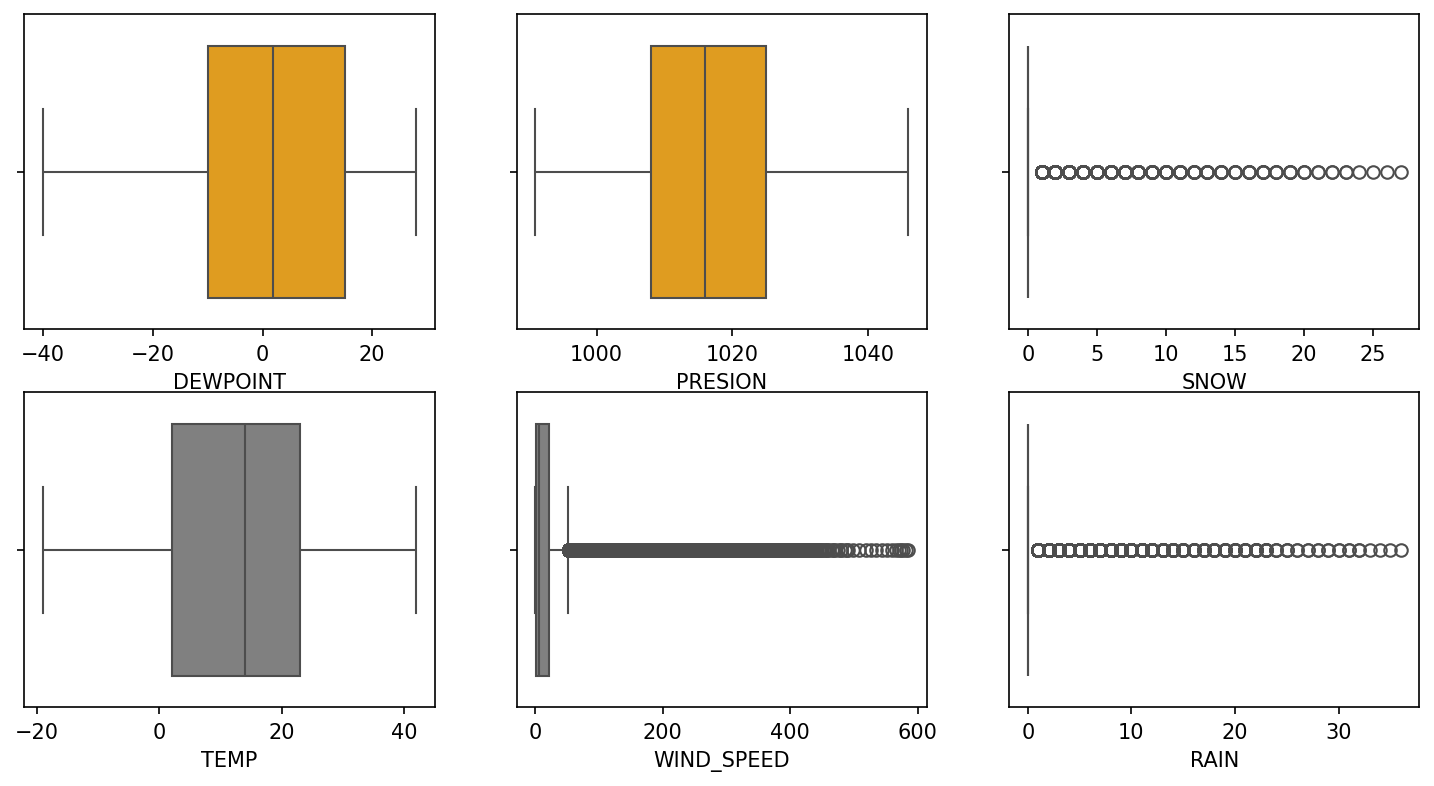

In [26]:
# HISTOGRAMA
# Analisis de outliers para cada variable

plt.rcParams["figure.dpi"] = 150

fig, axs = plt.subplots(2, 3, figsize=(12,6))

sns.boxplot(x="DEWPOINT", data=df, color='orange', ax=axs[0,0])
sns.boxplot(x="TEMP", data=df, color='grey', ax=axs[1,0])
sns.boxplot(x="PRESION", data=df, color='orange', ax=axs[0,1])
sns.boxplot(x="WIND_SPEED", data=df, color='grey', ax=axs[1,1])
sns.boxplot(x="SNOW", data=df, color='orange', ax=axs[0,2])
sns.boxplot(x="RAIN", data=df, color='grey', ax=axs[1,2])

plt.show

# SNOW y RAIN la mayoria de sus valores son 0, por eso la grafica de caja es una linea llena de outliers

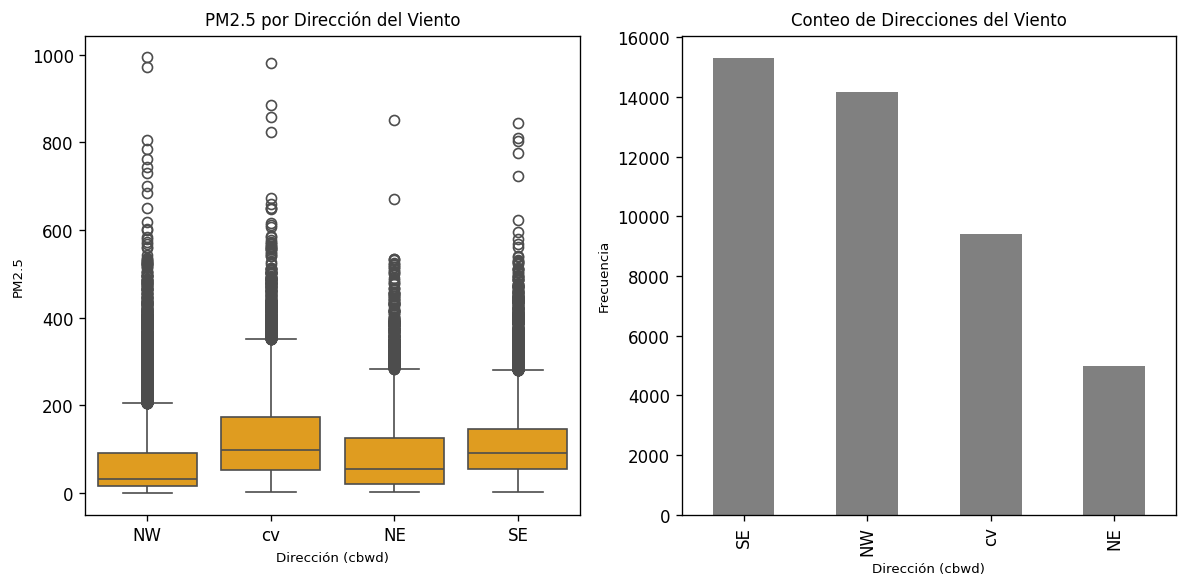

In [27]:
#GRAFICO DE BARRAS Y GRAFICO  DE CAJA Y BIGOTES
# Conteo de categorías
conteo = df['WIND_DIRECTION'].value_counts()

# Crear figura con dos subplots (2 filas, 1 columna)
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=120)

#Gráfico de caja para ver cómo afecta la dirección del viento o su calma ('cbwd') a los valores de PM2.5
sns.boxplot(x='WIND_DIRECTION', y='PM25', color='orange', data=df, ax=axes[0])
axes[0].set_title('PM2.5 por Dirección del Viento', fontsize=10)
axes[0].set_xlabel('Dirección (cbwd)', fontsize=8)
axes[0].set_ylabel('PM2.5', fontsize=8)

# --- Gráfico de barras ---
conteo.plot(kind='bar', color='grey', ax=axes[1])
axes[1].set_title("Conteo de Direcciones del Viento", fontsize=10)
axes[1].set_xlabel("Dirección (cbwd)", fontsize=8)
axes[1].set_ylabel("Frecuencia", fontsize=8)

plt.tight_layout()
plt.show()

# **En esta sección se preparan los dataset para ML mediante manipulación de los datos**

Se construyen columnas que reporten la variable categórica cbwd.
- Codificación (One-hot encoding) para la columna `WIND_DIRECTION` (única columna tipo string).

Se imputan los datos faltantes
- Creación de datasets con diferentes tipos de IMPUTACION para las columnas `PM25`.
- Opción 1: Eliminar nulos "df_clean"
- Opción 2: Rellenar con la media "df_mean"
- Opción 3: Rellenar con interpolación "df_mice"

Se normalizan las variables independientes
- Normalizar datasets

Generación de los df con los que se entrenarán los modelos.

Notas:

El df tiene 43,824 registros.
Se decide normalizar los datos hasta que se tienen o los datos NA eliminados o imputados para que no se creé un sesgo con datos y que la normalización refleje solo los datos útiles para el modelo.


In [28]:
print("La información con valores NA es:")
print(df.isna().sum())
print(" ")
print("Los valores de la unica columna tipo string (WIND_DIRECTION) son:")
print(df["WIND_DIRECTION"].value_counts())
print("Estos valores se les aplica One-hot encoding al ser muy pocas las categorias")

La información con valores NA es:
NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25              2067
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_DIRECTION       0
WIND_SPEED           0
SNOW                 0
RAIN                 0
FECHA                0
FECHA_SIN_H          0
dtype: int64
 
Los valores de la unica columna tipo string (WIND_DIRECTION) son:
WIND_DIRECTION
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64
Estos valores se les aplica One-hot encoding al ser muy pocas las categorias


In [29]:
# One-hot encoding para WIND_DIRECTION.
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[["WIND_DIRECTION"]])
encoded_columns = encoder.get_feature_names_out(["WIND_DIRECTION"])
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns)
#df_final = pd.concat([df.drop('WIND_DIRECTION', axis=1), encoded_df], axis=1) # Se decidió no eliminar la columna original
df_final = pd.concat([df, encoded_df], axis=1)
display(df_final.head(3))

# df_final es nuestro dataframe ya codificado!

# Comentario:
# pandas tmb hace esta separación en columnas de una forma mas sencilla...
# df_encoded_by_pandas = pd.get_dummies(df, columns=["WIND_DIRECTION"], dtype=int)
# print("\n--- pandas way (.get_dummies) ---")
# display(df_encoded_by_pandas.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,WIND_SPEED,SNOW,RAIN,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00,2010-01-01,0.0,1.0,0.0,0.0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00,2010-01-01,0.0,1.0,0.0,0.0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00,2010-01-01,0.0,1.0,0.0,0.0


AQUI VAN LOS LAGS DE LAS VARIABLES SOBRE EL DF DF_FINAL

In [30]:
# Para hacer los lagueos no vemos necesario meter todas las variables considerando
# que son fechas/horas ya implicitas en orden temporal, y una variable de índice.
# Variables climáticas continuas (las que tiene sentido analizar con correlación lineal en sus lagueos)
variables_continuas = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED']

resultados = {}
for var in variables_continuas:
    correlaciones = []
    for lag in range(1, 73):
        corr = df_final['PM25'].corr(df_final[var].shift(lag))
        correlaciones.append(corr)
    nombre_columna = var
    resultados[nombre_columna] = correlaciones

df_corr = pd.DataFrame(resultados, index=range(1, 73))
df_corr.index.name = 'lag'

display(df_corr)


,DEWPOINT,TEMP,PRESION,WIND_SPEED
lag,,,,
1,0.169031,-0.090645,-0.045570,-0.247820
2,0.163280,-0.088180,-0.043692,-0.245936
3,0.155795,-0.083090,-0.041491,-0.242372
4,0.147356,-0.076315,-0.038955,-0.237794
5,0.138542,-0.068515,-0.035659,-0.232565
...,...,...,...,...
68,-0.077996,-0.122172,0.141171,-0.020693
69,-0.077589,-0.123461,0.141314,-0.017658
70,-0.077211,-0.123613,0.141270,-0.015191


In [31]:
#Buscamos el mejor lagueo
mejor_lag_por_variable = df_corr.abs().idxmax()
valor_correlacion = df_corr.abs().max()

resumen = pd.DataFrame({
    'mejor_lag': mejor_lag_por_variable,
    'correlacion_abs': valor_correlacion
})
display(resumen.sort_values('correlacion_abs', ascending=False))

,mejor_lag,correlacion_abs
WIND_SPEED,1,0.247820
DEWPOINT,1,0.169031
PRESION,47,0.143103
TEMP,70,0.123613


In [71]:
# Ordena por tiempo antes de crear lags
df_final = df_final.sort_values('FECHA').reset_index(drop=True)

# Vamos a usar ventanas de 4hrs en los lagueos para no usar tanto Disco duro o RAM
lags_a_usar = [1, 5, 9, 13, 17, 21, 25]
variables_para_laguear = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED']

for var in variables_para_laguear:
    for lag in lags_a_usar:
        df_final[f'{var}_lag{lag}'] = df_final[var].shift(lag)

# Elimina las filas iniciales que quedan con NaN por el shift
df_final = df_final.dropna(subset=[f'{var}_lag{max(lags_a_usar)}' for var in variables_para_laguear])
df_final = df_final.reset_index(drop=True)

display(df_final.head())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,PRESION_lag17,PRESION_lag21,PRESION_lag25,WIND_SPEED_lag1,WIND_SPEED_lag5,WIND_SPEED_lag9,WIND_SPEED_lag13,WIND_SPEED_lag17,WIND_SPEED_lag21,WIND_SPEED_lag25
0,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,1017.0,1018.0,1021.0,1.79,0.89,1.79,37.56,24.15,12.97,1.79
1,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,1017.0,1017.0,1020.0,2.68,1.79,2.68,40.69,27.28,16.10,4.92
2,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,...,1017.0,1017.0,1019.0,3.57,2.68,1.79,43.82,31.30,19.23,6.71
3,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,...,1017.0,1017.0,1019.0,5.36,0.89,1.79,0.89,34.43,21.02,9.84
4,30,2010,1,2,5,109.0,-7,-6.0,1022.0,SE,...,1015.0,1017.0,1018.0,6.25,1.79,0.89,1.79,37.56,24.15,12.97


In [38]:
# se aplica la transformacion de hrs y meses para crear los ciclos de 24hrs y 12 meses
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['HOUR'] / 24)
df_final['hour_cos'] = np.cos(2 * np.pi * df_final['HOUR'] / 24)
df_final['month_sin'] = np.sin(2 * np.pi * df_final['MONTH'] / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final['MONTH'] / 12)
print(df_final)

          NO  YEAR  MONTH  DAY  HOUR  PM25  DEWPOINT  TEMP  PRESION  \
0          1  2010      1    1     0   NaN       -21 -11.0   1021.0   
1          2  2010      1    1     1   NaN       -21 -12.0   1020.0   
2          3  2010      1    1     2   NaN       -21 -11.0   1019.0   
3          4  2010      1    1     3   NaN       -21 -14.0   1019.0   
4          5  2010      1    1     4   NaN       -20 -12.0   1018.0   
...      ...   ...    ...  ...   ...   ...       ...   ...      ...   
43819  43820  2014     12   31    19   8.0       -23  -2.0   1034.0   
43820  43821  2014     12   31    20  10.0       -22  -3.0   1034.0   
43821  43822  2014     12   31    21  10.0       -22  -3.0   1034.0   
43822  43823  2014     12   31    22   8.0       -22  -4.0   1034.0   
43823  43824  2014     12   31    23  12.0       -21  -3.0   1034.0   

      WIND_DIRECTION  ...               FECHA  FECHA_SIN_H  WIND_DIRECTION_NE  \
0                 NW  ... 2010-01-01 00:00:00   2010-01-01        

**Sección para generar el df_clean: SIN nulos, CON columnas categóricas adicionales y CON columnas normalizadas**

In [39]:
# df limpio de NA. Crea nuevo dataset que elimina las filas con NAs determinado por la columna pm2.5.
df_clean = df_final.dropna(subset=['PM25'])
print(len(df_clean))
print("Verificación: ", 43824-2067)
display(df_clean.head(3))


41757
Verificación:  41757


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,FECHA,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,...,2010-01-02 00:00:00,2010-01-02,0.0,0.0,1.0,0.0,0.000000,1.000000,0.5,0.866025
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,2010-01-02 01:00:00,2010-01-02,0.0,0.0,1.0,0.0,0.258819,0.965926,0.5,0.866025
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,2010-01-02 02:00:00,2010-01-02,0.0,0.0,1.0,0.0,0.500000,0.866025,0.5,0.866025


In [40]:
df_final.columns

Index(['NO', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'PM25', 'DEWPOINT', 'TEMP',
       'PRESION', 'WIND_DIRECTION', 'WIND_SPEED', 'SNOW', 'RAIN', 'FECHA',
       'FECHA_SIN_H', 'WIND_DIRECTION_NE', 'WIND_DIRECTION_NW',
       'WIND_DIRECTION_SE', 'WIND_DIRECTION_cv', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos'],
      dtype='str')

In [41]:
# Para el escalado de variables, dado las propiedades de outliers de nuestro dataset
# Elegimos RobustScaler
# Preprocesamos los datos: Estadarización

# Para df_clean, define las columnas a escalar
cols_to_scale = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED', 'SNOW', 'RAIN', 'DEWPOINT_lag1', 'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13', 'DEWPOINT_lag13', 'DEWPOINT_lag17',
       'DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5',
       'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25',
       'PRESION_lag1', 'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13',
       'PRESION_lag17', 'PRESION_lag21', 'PRESION_lag25', 'WIND_SPEED_lag1',
       'WIND_SPEED_lag5', 'WIND_SPEED_lag9', 'WIND_SPEED_lag13',
       'WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos']

#Inicia scaler
scaler = StandardScaler()

# Ajusta y transforma solo esas columnas
scaled_values = scaler.fit_transform(df_clean[cols_to_scale])

# Crear un DataFrame con las columnas escaladas
scaled_df = pd.DataFrame(scaled_values,
                         columns=[col + "_scaled" for col in cols_to_scale],
                         index=df_clean.index)

# Concatenar al DataFrame original
df_clean_scaled = pd.concat([df_clean, scaled_df], axis=1)

display(df_clean_scaled.head(3))

#Este código lo teníamos originalmente, pero solo dejaba las variables estandarizadas
#ct = ColumnTransformer(
#    transformers=[
#        ('scaler', StandardScaler(), cols_to_scale)
#    ],
#    remainder='passthrough'
#)
## Fit and transform the data
## Note: By default, this outputs a NumPy array or a Pandas DataFrame depending on your sklearn configuration
#scaled_array = ct.fit_transform(df_clean)

KeyError: "['DEWPOINT_lag1', 'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13', 'DEWPOINT_lag17', 'DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5', 'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25', 'PRESION_lag1', 'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13', 'PRESION_lag17', 'PRESION_lag21', 'PRESION_lag25', 'WIND_SPEED_lag1', 'WIND_SPEED_lag5', 'WIND_SPEED_lag9', 'WIND_SPEED_lag13', 'WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25'] not in index"

In [42]:
df_clean_scaled.info()

NameError: name 'df_clean_scaled' is not defined

In [43]:
# Análisis de métricas principales de la información
# Estadísticas básicas sin considerar las fechas ni variables categóricas
df_clean_scaled.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

NameError: name 'df_clean_scaled' is not defined

In [44]:
# Expotar .csv
# DFs con los nombres con el sub "_clean_scaled" y "_mice_scaled"
df_clean_scaled.to_csv("PRSA_data_clean_scaled.csv", sep='\t', encoding='utf-8', index=False, header=True)

NameError: name 'df_clean_scaled' is not defined

**Sección para generar el df_imputado: CON nulos-imputados, CON columnas categóricas adicionales y CON columnas normalizadas**

In [45]:
# Iterative Imputation (MICE), supuestamente el mejor
df_numerico = df_final.select_dtypes(include=["number"])

# Crea una copia de la columna PM25
#df_numerico["PM25_MICE"] = df_numerico["PM25"]

# 3. Aplicamos el imputador MICE sobre todas las columnas numéricas
#    - strategy: 'mean' es más estable para evitar overflow
#    - tol: tolerancia más estricta para convergencia
#    - max_iter: número de iteraciones
mice_imputer = IterativeImputer(max_iter=10, random_state=0, tol=1e-3)

# 4. Aplicamos la imputación sobre todas las columnas numéricas
mice_imputer_data = mice_imputer.fit_transform(df_numerico)

# 5. Reconstruimos el DataFrame imputado con los mismos nombres de columnas
df_imputed_mice = pd.DataFrame(mice_imputer_data, columns=df_numerico.columns)

# 6. Verificamos resultados
display(df_imputed_mice.head(3))
display(df_imputed_mice[["PM25"]].isnull().sum())

# 6. Nos quedamos solo con la columna imputada y la renombro  PM25_MICE
df_imputed_mice = df_imputed_mice[["PM25"]]
df_imputed_mice = df_imputed_mice.rename(columns={"PM25": "PM25_MICE"})

# 6. Verificamos resultados
display(df_imputed_mice.head(3))


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos
0,1.0,2010.0,1.0,1.0,0.0,97.467926,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.000000,0.5,0.866025
1,2.0,2010.0,1.0,1.0,1.0,99.094379,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0,0.258819,0.965926,0.5,0.866025
2,3.0,2010.0,1.0,1.0,2.0,95.754981,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0,0.500000,0.866025,0.5,0.866025


PM25    0
dtype: int64

,PM25_MICE
0,97.467926
1,99.094379
2,95.754981


In [46]:
#integro un df con las variables que ya tenía más la imputada
# Concatenar al DataFrame
df_imputed_mice = pd.concat([df_final, df_imputed_mice], axis=1)
display(df_imputed_mice.head(3))

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos,PM25_MICE
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,...,2010-01-01,0.0,1.0,0.0,0.0,0.000000,1.000000,0.5,0.866025,97.467926
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,...,2010-01-01,0.0,1.0,0.0,0.0,0.258819,0.965926,0.5,0.866025,99.094379
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,...,2010-01-01,0.0,1.0,0.0,0.0,0.500000,0.866025,0.5,0.866025,95.754981


In [47]:
df_imputed_mice.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   NO                 43824 non-null  int64         
 1   YEAR               43824 non-null  int64         
 2   MONTH              43824 non-null  int64         
 3   DAY                43824 non-null  int64         
 4   HOUR               43824 non-null  int64         
 5   PM25               41757 non-null  float64       
 6   DEWPOINT           43824 non-null  int64         
 7   TEMP               43824 non-null  float64       
 8   PRESION            43824 non-null  float64       
 9   WIND_DIRECTION     43824 non-null  str           
 10  WIND_SPEED         43824 non-null  float64       
 11  SNOW               43824 non-null  int64         
 12  RAIN               43824 non-null  int64         
 13  FECHA              43824 non-null  datetime64[us]
 14  FECHA_SIN_H      

In [48]:
# Escalado / Normalización de variables,

# Para df_imputed_mice, define las columnas a escalar
cols_to_scale = ['DEWPOINT', 'TEMP', 'PRESION', 'WIND_SPEED', 'SNOW', 'RAIN', 'DEWPOINT_lag1', 'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13', 'DEWPOINT_lag13', 'DEWPOINT_lag17',
       'DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5',
       'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25',
       'PRESION_lag1', 'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13',
       'PRESION_lag17', 'PRESION_lag21', 'PRESION_lag25', 'WIND_SPEED_lag1',
       'WIND_SPEED_lag5', 'WIND_SPEED_lag9', 'WIND_SPEED_lag13',
       'WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25', 'hour_sin',
       'hour_cos', 'month_sin', 'month_cos']

#Inicia scaler
scaler = StandardScaler()

#Me quedo sólo con las columnas cols_to_scale -- pruebas porque no estaba corriendo bien
#df_imputed_mice_cols = df_imputed_mice[cols_to_scale]
#df_imputed_mice_cols.info()
#print(df_imputed_mice_cols.shape)

# Ajusta y transforma solo esas columnas
scaled_values_mice = scaler.fit_transform(df_imputed_mice[cols_to_scale])

# Crear un DataFrame con las columnas escaladas
scaled_mice_df = pd.DataFrame(scaled_values_mice,
                         columns=[col + "_scaled" for col in cols_to_scale],
                         index=df_imputed_mice.index)

# Concatenar al DataFrame original
df_imputed_mice_scaled = pd.concat([df_imputed_mice, scaled_mice_df], axis=1)

display(df_imputed_mice_scaled.head(3))


# Fit and transform the data
# Note: By default, this outputs a NumPy array or a Pandas DataFrame depending on your sklearn configuration
#scaled_array = ct.fit_transform(df)
# Para df_imputed_mice



KeyError: "['DEWPOINT_lag1', 'DEWPOINT_lag5', 'DEWPOINT_lag9', 'DEWPOINT_lag13', 'DEWPOINT_lag17', 'DEWPOINT_lag21', 'DEWPOINT_lag25', 'TEMP_lag1', 'TEMP_lag5', 'TEMP_lag9', 'TEMP_lag13', 'TEMP_lag17', 'TEMP_lag21', 'TEMP_lag25', 'PRESION_lag1', 'PRESION_lag5', 'PRESION_lag9', 'PRESION_lag13', 'PRESION_lag17', 'PRESION_lag21', 'PRESION_lag25', 'WIND_SPEED_lag1', 'WIND_SPEED_lag5', 'WIND_SPEED_lag9', 'WIND_SPEED_lag13', 'WIND_SPEED_lag17', 'WIND_SPEED_lag21', 'WIND_SPEED_lag25'] not in index"

In [ ]:
df_imputed_mice_scaled.info()

In [49]:
df_imputed_mice_scaled.drop(columns=["NO", "YEAR", "MONTH", "DAY", "HOUR","FECHA", "FECHA_SIN_H" ]).describe()

NameError: name 'df_imputed_mice_scaled' is not defined

In [50]:
# Expotar .csv
#DFs con los nombres con el sub "_clean" y "_mice"
df_imputed_mice_scaled.to_csv("PRSA_data_mice_scaled.csv", sep='\t', encoding='utf-8', index=False, header=True)

NameError: name 'df_imputed_mice_scaled' is not defined

Con las consultas de los estadísticos de las tres bases de datos se hace una revisión de los cambios al eliminar o imputar la información

# **Programaciones NO usadas o eliminadas del flujo final**
Ooo
Si corren...

<function matplotlib.pyplot.show(close=None, block=None)>

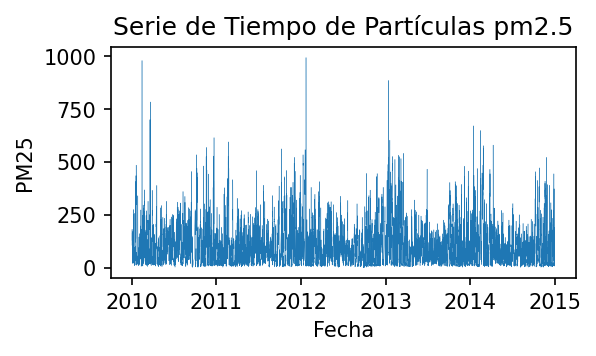

In [51]:
# SERIE DE TIEMPO
# Configuración de los gráficos
plt.figure(figsize=(4, 2))

# 1. Gráfico para ver la serie
sns.lineplot(x="FECHA", y="PM25", data=df, linewidth=0.2)
plt.title('Serie de Tiempo de Partículas pm2.5')
plt.xlabel('Fecha')

plt.show

Text(0.5, 0, 'Concentración μg/m³')

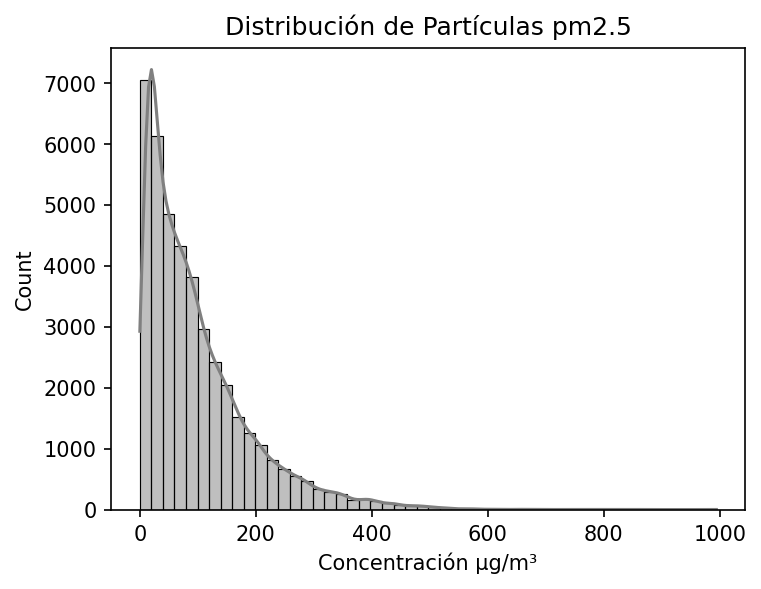

In [52]:
# HISTOGRAMA
# Configuración de los gráficos
plt.figure(figsize=(12, 4))

# Gráfico para ver la distribución de pm2.5 e identificar sesgos o valores atípicos (outliers)
plt.subplot(1, 2, 1)
sns.histplot(df['PM25'].dropna(), bins=50, kde=True, color='grey')
plt.title('Distribución de Partículas pm2.5')
plt.xlabel('Concentración μg/m³')

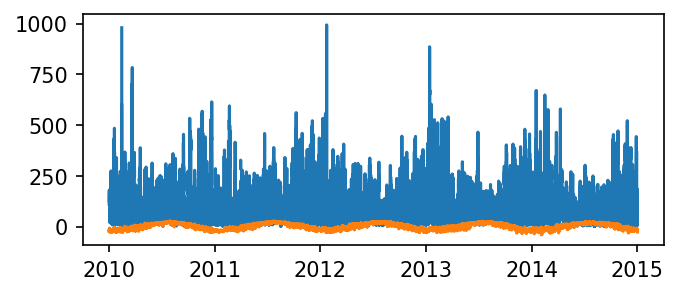

In [53]:
plt.figure(figsize=(5, 2))
plt.plot(df["FECHA"], df["PM25"], label="pm2.5")
plt.plot(df["FECHA"], df["DEWPOINT"], label="DEWP")

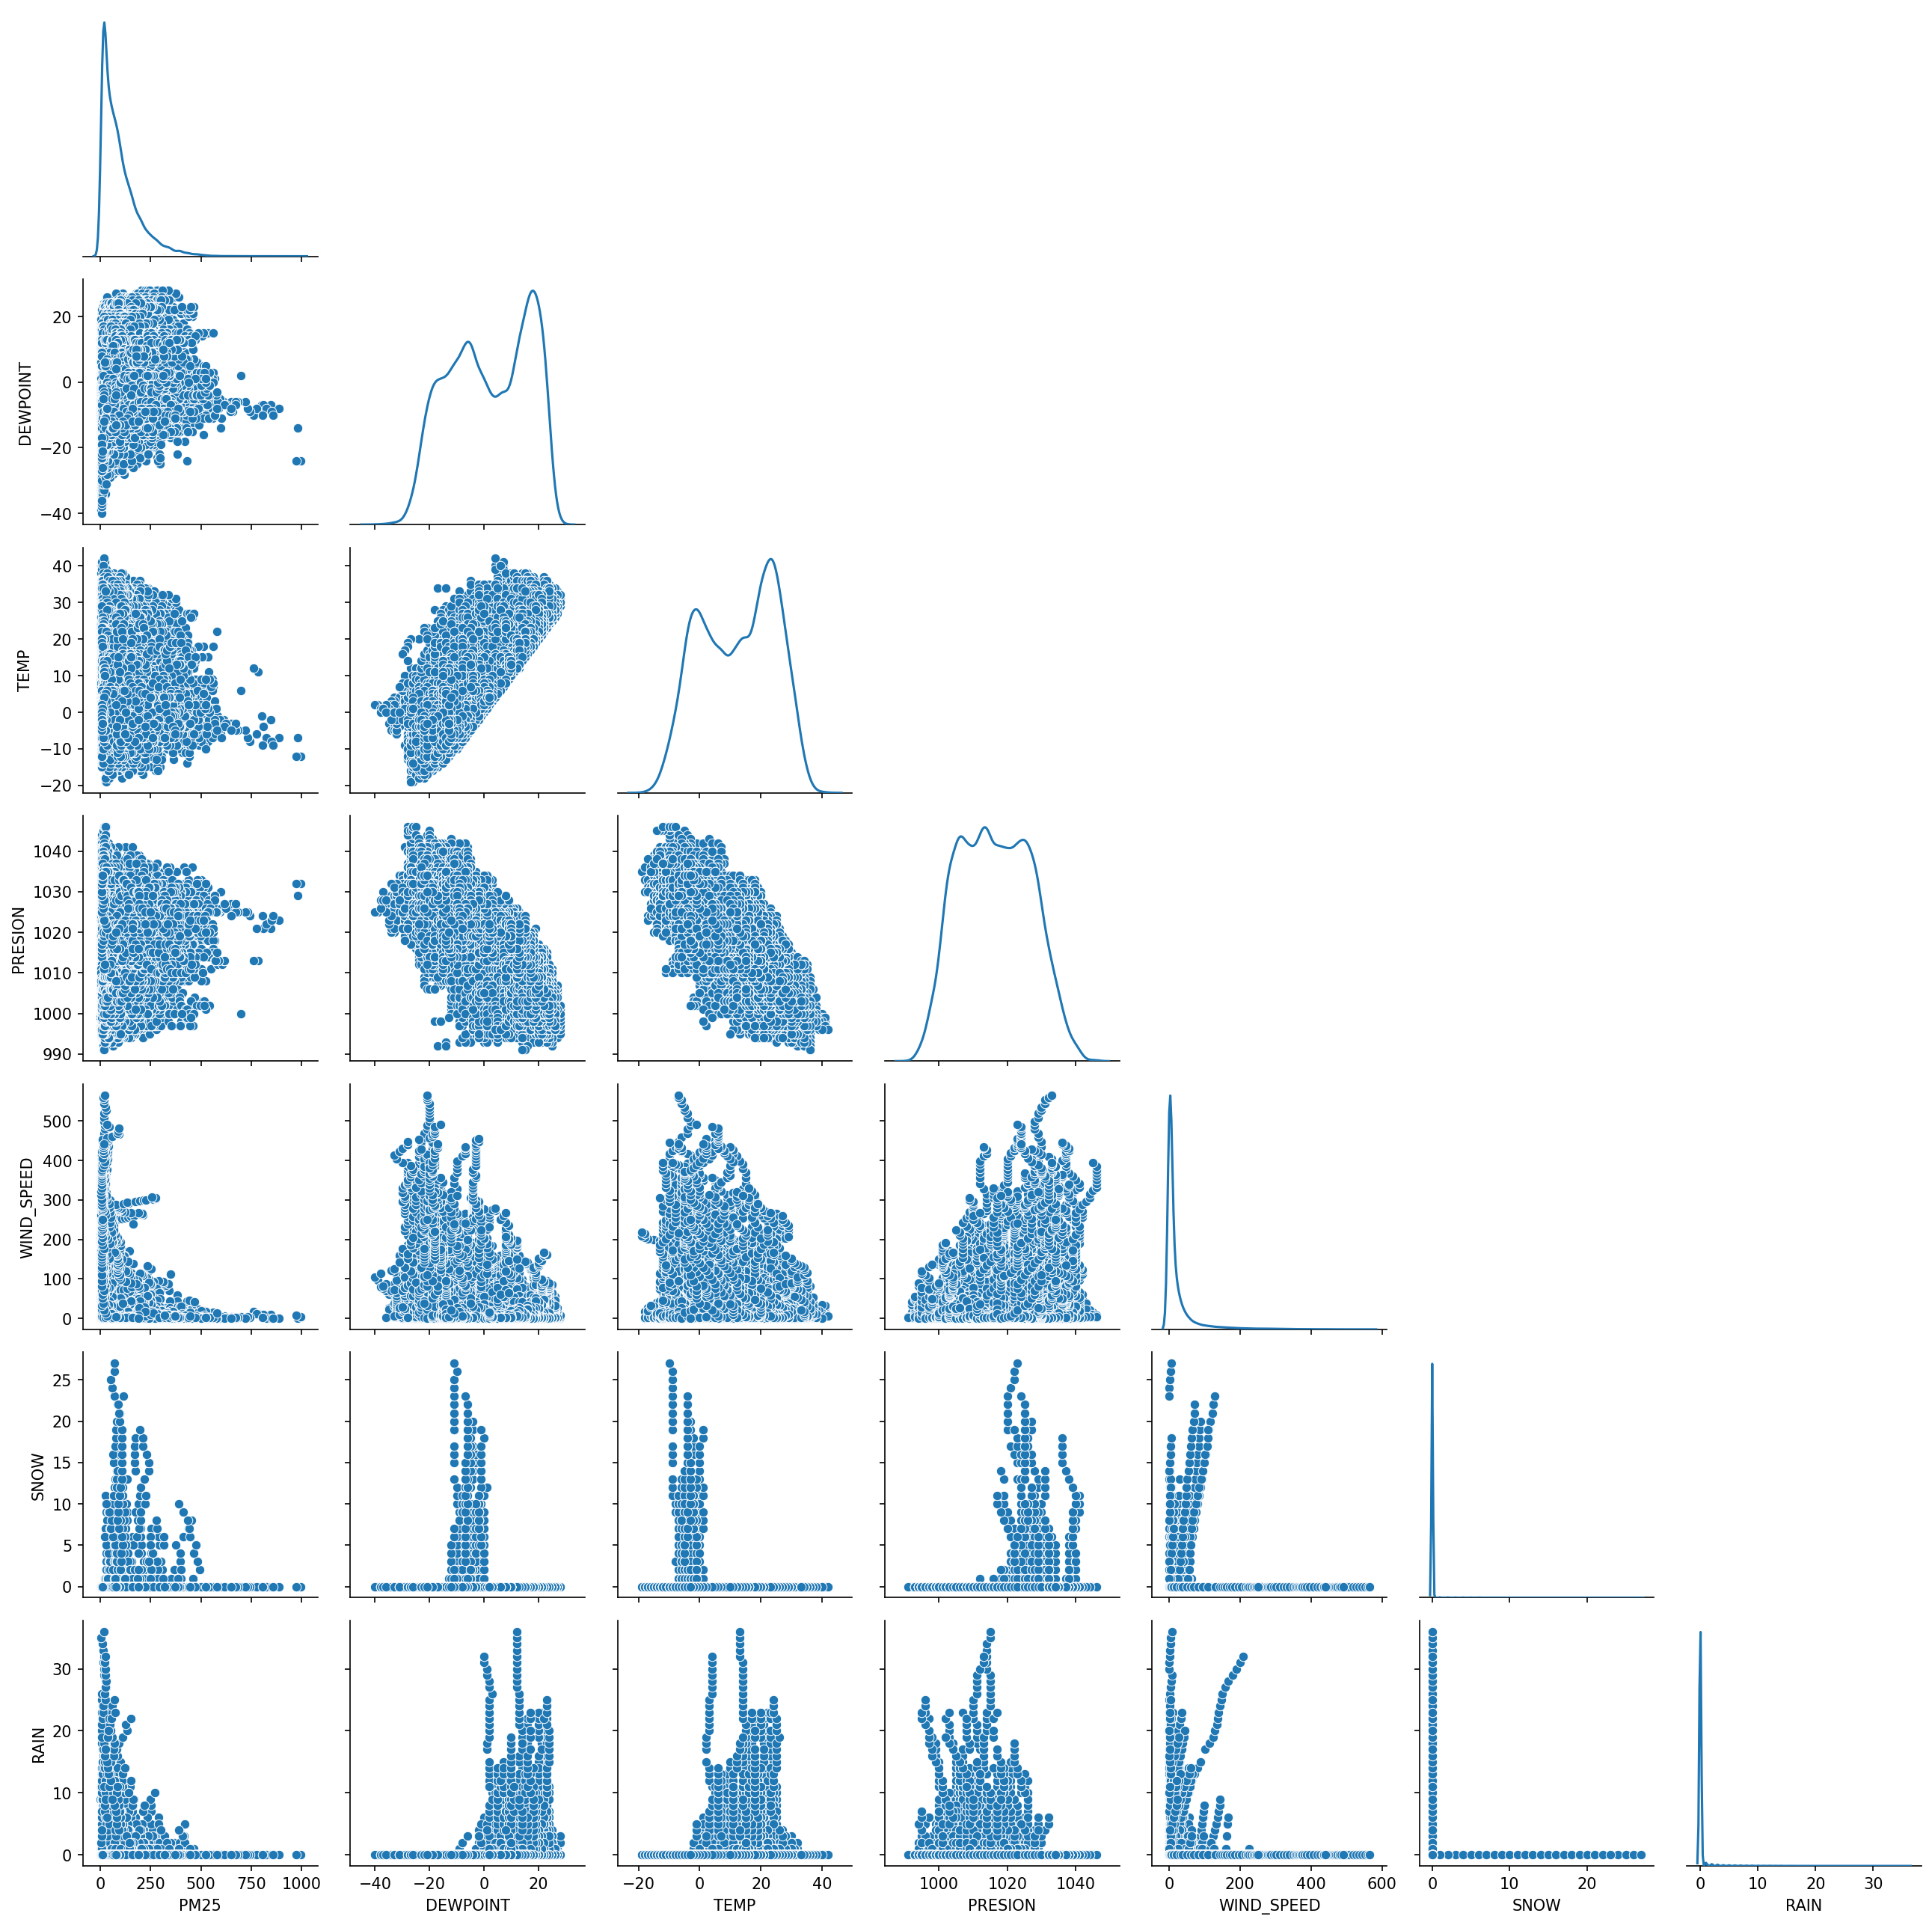

In [54]:
g = sns.PairGrid(df_clean[["PM25", "DEWPOINT", "TEMP", "PRESION", "WIND_SPEED", "SNOW", "RAIN"]],
                 diag_sharey=False,
                 corner=True
                )
g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)
# llevar a la otra fase

In [55]:
df["FECHA"].sample(3)


19970   2012-04-12 02:00:00
25648   2012-12-04 16:00:00
36750   2014-03-12 06:00:00
Name: FECHA, dtype: datetime64[us]

In [ ]:
# Rellenar nulos con la mediana
# df['pm2.5'] = df['pm2.5'].fillna(df['pm2.5'].median())

In [56]:
# K-Nearest Neighbors (KNN), este tipo de imputación es bueno para datasets con variables agrupadas
# Que WIND_DIRECTION es la única variable categorica (factor)

df_numerico = df_final.select_dtypes(include=["number"])

knn_imputer = KNNImputer(n_neighbors=2)
imputed_data = knn_imputer.fit_transform(df_numerico)
df_imputed_KNN = pd.DataFrame(imputed_data, columns=df_numerico.columns)

# df_imputer_KNN es nuestro dataframe con metodo de imputación KNN
# en este la variable a modelas sigue siendo PM25

display(df_imputed_KNN.head(3))
display(df_imputed_KNN.isnull().sum())

,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_SPEED,SNOW,RAIN,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos
0,1.0,2010.0,1.0,1.0,0.0,138.5,-21.0,-11.0,1021.0,1.79,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.000000,0.5,0.866025
1,2.0,2010.0,1.0,1.0,1.0,138.5,-21.0,-12.0,1020.0,4.92,0.0,0.0,0.0,1.0,0.0,0.0,0.258819,0.965926,0.5,0.866025
2,3.0,2010.0,1.0,1.0,2.0,138.5,-21.0,-11.0,1019.0,6.71,0.0,0.0,0.0,1.0,0.0,0.0,0.500000,0.866025,0.5,0.866025


NO                   0
YEAR                 0
MONTH                0
DAY                  0
HOUR                 0
PM25                 0
DEWPOINT             0
TEMP                 0
PRESION              0
WIND_SPEED           0
SNOW                 0
RAIN                 0
WIND_DIRECTION_NE    0
WIND_DIRECTION_NW    0
WIND_DIRECTION_SE    0
WIND_DIRECTION_cv    0
hour_sin             0
hour_cos             0
month_sin            0
month_cos            0
dtype: int64

In [57]:
#Gusrdarmos la programación para sacar la mediana y medias en la imputación pero no se sigue todo el proceso para normalizar las variables

# No es del todo claro qué metodo de imputación se elegirá por lo que se crearán diferetes dataset con diferentes metodos de imputación
df_imputed_mean = df_final.copy()
df_imputed_median = df_final.copy()

# imputaición con media (no aprecia tanto los outliers)
numeric_imputer_mean = SimpleImputer(strategy="mean")
df_imputed_mean["PM25_IMPUTED_MEAN"] = numeric_imputer_mean.fit_transform(df[["PM25"]])
# imputación con mediana (Maneja mejor los outliers)
numeric_imputer_median = SimpleImputer(strategy="median")
df_imputed_median["PM25_IMPUTED_MEDIAN"] = numeric_imputer_median.fit_transform(df[["PM25"]])

# Aqui nuestras columnas por modelar son:
# - PM25_IMPUTED_MEAN
# - PM25_IMPUTED_MEDIAN

print("Base de datos Imputada")
display(df_imputed_mean.sample(3))
display(df_imputed_median.sample(3))

# Comentarios:
# Existe otra forma mas rápida con Pandas, aunque se recomienda usar la de scikit-learn
# df_encoded_by_pandas["PM25_IMPUTED_MEAN"] = df["PM25"].fillna(df["PM25"].mean())
# df_encoded_by_pandas["PM25_IMPUTED_MEDIAN"] = df["PM25"].fillna(df["PM25"].median())
# print("\nBase de datos Imputada (con pandas)")
# display(df_encoded_by_pandas.head(3))

Base de datos Imputada


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos,PM25_IMPUTED_MEAN
2179,2180,2010,4,1,19,17.0,-19,10.0,1018.0,NW,...,2010-04-01,0.0,1.0,0.0,0.0,-0.965926,0.258819,0.866025,-0.500000,17.0
15575,15576,2011,10,11,23,199.0,14,15.0,1021.0,SE,...,2011-10-11,0.0,0.0,1.0,0.0,-0.258819,0.965926,-0.866025,0.500000,199.0
9265,9266,2011,1,22,1,130.0,-18,-9.0,1028.0,NW,...,2011-01-22,0.0,1.0,0.0,0.0,0.258819,0.965926,0.500000,0.866025,130.0


,NO,YEAR,MONTH,DAY,HOUR,PM25,DEWPOINT,TEMP,PRESION,WIND_DIRECTION,...,FECHA_SIN_H,WIND_DIRECTION_NE,WIND_DIRECTION_NW,WIND_DIRECTION_SE,WIND_DIRECTION_cv,hour_sin,hour_cos,month_sin,month_cos,PM25_IMPUTED_MEDIAN
27899,27900,2013,3,8,11,139.0,-5,20.0,1006.0,SE,...,2013-03-08,0.0,0.0,1.0,0.0,0.258819,-0.965926,1.000000e+00,6.123234e-17,139.0
12797,12798,2011,6,18,5,257.0,19,20.0,1008.0,NE,...,2011-06-18,1.0,0.0,0.0,0.0,0.965926,0.258819,1.224647e-16,-1.000000e+00,257.0
32393,32394,2013,9,11,17,72.0,12,28.0,1012.0,SE,...,2013-09-11,0.0,0.0,1.0,0.0,-0.965926,-0.258819,-1.000000e+00,-1.836970e-16,72.0
